# ランダムグッズ「9割が嫌い」の数理（構造分析編）

推しのアクリルスタンドが欲しくて10個買ったのに、目当ては1つも出なかった。こういう経験をした人は少なくないはずです。

2026年、この「ランダム販売」について大規模な消費者意識調査が公開されました。株式会社Hamaru Strategyによる「ランダムグッズに関する消費者意識調査2026」です。この調査結果を出発点に、**ランダム販売への不満がどこから生まれるのかを、確率とシミュレーションで分解します。**

## 何を調べたか

ランダムグッズ（ガチャ・ブラインド商品）への不満は、「確率が不公平だから」という理屈でよく語られます。しかし本当にそうなのか。**確率設定が完全に公平だったとしても、この不満は構造的に生まれるのではないか**、という仮説を、公開されている集計値とシミュレーションで検証しました。

## 何が分かったか

1. **支払意思額と必要な期待コストの間に大きな乖離がある** ── n種類のうち1種を狙うと期待コストは単価のn倍だが、消費者が「確定販売なら払える」と答えた額は最も寛容な層でもその半分に届かない
2. **余剰は消えず、企業から消費者へ移動する** ── ランダム販売は企業の在庫リスクを減らす代わりに、消費者の手元にダブりを積み上げる
3. **確率が完全に公平でも、需要の偏りだけで不公平感が生まれる** ── 供給が一様でも、人気キャラへの需要が偏っていれば、人気キャラを推す人ほど構造的に損をする

## 何が分からなかったか

- 設問39の支払意思額データは種類数10（n=10）でしか測定されておらず、他の種類数への一般化はできません
- 交換シミュレーションが測っているのは「マッチング成立可能性」であり、ファンコミュニティで実際に使われる交換レートとは別の概念です
- 余剰の移動モデルは企業が需要予測をしない前提であり、予測精度が向上すればデッドストックは減少しうるものです
- 用いた需要分布（Zipf則）はあくまで仮定であり、実際のキャラクター人気分布を実測したものではありません

（詳細は本ノートブック末尾「4. 結論と限界」を参照してください）

## リンク

- 動画（前編）：（URLを追記）
- note記事（前編）：（URLを追記）
- データ出典：株式会社Hamaru Strategy「ランダムグッズに関する消費者意識調査2026」
  https://ferventvoice.com/index.html

## 姉妹エピソード

同じ調査を別の角度から読んだ後編があります。設問12のクロス集計（「手に入らなかった経験が全くない層ほど支出額が高い」という逆転現象）を、ブートストラップ法でどこまで信頼できるか検証しました。

→ [ep03: ランダムグッズ「9割が嫌い」の数理（サンプリング検証編）](../ep03_random_goods_sampling/random_goods_sampling.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx   # 交換の1対1マッチング（最大マッチング）に使用
from matplotlib.ticker import FuncFormatter

# 日本語フォント設定。環境によって表示可能なフォントが異なるため、
# 実行環境に応じて 'Yu Gothic' / 'MS Gothic' / 'IPAexGothic' 等に調整してください。
plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# 乱数シードはノートブック全体で固定（再現性のため）
rng = np.random.default_rng(20260801)

# 配色
C_MAIN, C_SUB, C_WARN, C_GRAY = '#2a78d6', '#eb6834', '#e34948', '#888780'
yen = FuncFormatter(lambda v, p: f'{v:,.0f}円')

# ---- 出典キャプション -----------------------------------------------
# 図によってデータの性質が異なるため、3種類のキャプションを使い分ける。
# 全図に一律で「調査データ」と表記すると、シミュレーション結果まで
# 調査の実測値だと誤認させてしまうため、必ず区別すること。
SRC_URL = 'https://ferventvoice.com/index.html'
SRC_SURVEY = ('出典：株式会社Hamaru Strategy『ランダムグッズに関する消費者意識調査2026』\n' + SRC_URL)
SRC_SIM    = '筆者作成（シミュレーションによる。調査データは使用していない）'

def caption(fig, text):
    # 図の下部に出典キャプションを付ける。
    fig.text(0.005, -0.02, text, ha='left', va='top', fontsize=8,
              color='#666666', transform=fig.transFigure)
    return fig

print('setup done')

setup done


## 1. データの取得

このプロジェクトでは調査の個票データは公開されていません。公開されているのは度数分布・クロス集計などの**集計値のみ**です。そのため、このノートブックに「データを取得するコード」は存在しません。代わりに、報告書に掲載されている集計値を分析用の定数として書き起こします。

以下の定数は、記事本文に登場した数値をすべて含みます（分析に直接使わない数値も、記事の文脈を再現するために定義しています）。

In [2]:
# 出典：株式会社Hamaru Strategy「ランダムグッズに関する消費者意識調査2026」
# https://ferventvoice.com/index.html
# 取得日：（実行者が記入）
# 引用条件：（実行者が記入。「引用の範囲を超えて収益を得る行為の禁止」等の要点）
#
# 以下は同報告書で公開されている集計値を、分析用の定数として書き起こしたもの。
# 個票データは公開されていないため、算出には使用していない。

# ---- 調査概要 ---------------------------------------------------------
N_RESPONDENTS = 35866          # 総回答数
SURVEY_PERIOD = '2026-03-28 〜 2026-04-03（1週間）'
FREE_TEXT_CHARS = 2_690_000    # 自由記述の総文字数（概数）

# ---- 全体の不満・意向（記事冒頭で言及） --------------------------------
PCT_DISLIKE = 89.9              # ランダム販売を「嫌い」「非常に嫌い」の合計
PCT_WANT_SELECTABLE = 89.7      # 単価が上がっても選んで買える形式を望む
PCT_IMPRESSION_WORSENED = 85.2  # ランダム販売でコンテンツへの印象が悪化した経験
PCT_MAKER_DISLIKE = 84.3        # 製造・販売に関わる回答者でも「嫌い」と回答した割合

# ---- 設問11：1回のランダムグッズ購入にかけた最大金額（度数分布） --------
Q11_BINS_UPPER = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])   # 「〜n万円」の上限（単位：万円）
Q11_PCT_CLOSED = np.array([32.3, 22.5, 12.8, 9.5, 3.4, 6.1, 2.5, 1.5, 1.5, 0.5])  # 各ビンの回答割合(%)
Q11_PCT_OPEN = 7.4              # 「10万円〜」（上限なしの開放ビン）の回答割合(%)
Q11_MEAN_RAW = 37600            # 平均（全データ）
Q11_MEAN_TRIM = 20256           # 10%トリム平均（報告書が採用している代表値）
Q11_MEDIAN = 15000              # 中央値

# ---- 設問16：不満の内訳（複数回答, n=35,866）上位2項目 -------------------
Q16_TOP1_PCT = 98.5   # 欲しいものが手に入らない可能性がある
Q16_TOP2_PCT = 91.6   # 通常販売のグッズよりお金が余計にかかる

# ---- 設問39：支払意思額（5価格帯 × 9パーセンタイル、全45セル） -----------
# 「10種ランダム・うち自分の欲しい種類が1種類」に条件を固定した上で、
# 「確定販売なら最大いくらまで出せるか」を尋ねたもの。単価に対する倍率。
Q39_PRICES = [300, 500, 800, 1000, 1500]                 # 単価（円）
Q39_PCTS = [90, 80, 70, 60, 50, 40, 30, 20, 10]           # 「この割合の人が出せる」というパーセンタイル
Q39_MULT = {
    300:  [1.4, 1.6, 1.9, 2.1, 2.3, 2.6, 2.9, 3.2, 3.7],
    500:  [1.3, 1.6, 1.9, 2.1, 2.4, 2.7, 3.0, 3.4, 4.1],
    800:  [1.2, 1.4, 1.6, 1.7, 1.9, 2.2, 2.4, 2.8, 3.4],
    1000: [1.2, 1.4, 1.7, 1.9, 2.1, 2.4, 2.7, 3.1, 3.8],
    1500: [1.1, 1.3, 1.5, 1.7, 1.9, 2.1, 2.4, 2.8, 3.5],
}
Q39_N_TYPES = 10   # この設問が固定している種類数（n=10）。他のnへの外挿はしない。

# ---- 設問44：許容ライン・拒絶ラインの集計表 ------------------------------
Q44_ACCEPT_TYPES, Q44_ACCEPT_PRICE = 5, 500      # 許容できる：5種類以内・500円以下
Q44_REJECT_TYPES, Q44_REJECT_PRICE = 10, 1000    # 受け入れられない：10種類以上・1,000円以上

# ---- 設問48：メーカーヒアリング（原文引用は本文記事側で1〜2本に限定） -----
Q48_INVENTORY_QUOTE = 'キャラクター人気の差による在庫リスクを減らせることが大きく、やめられない'
Q48_UNIT_PRICE_RATIO_RANGE = (5, 10)   # 選んで買える場合との客単価差（複数社ヒアリングの要約、概数）

# ---- 設問32・33：交換レート ---------------------------------------------
Q32_EXCHANGE_RATE_EXISTS_PCT = 70.6   # 交換レートが存在すると回答した割合
Q33_POPULAR_HARD_TO_MATCH_PCT = 67.2  # 推しが人気で交換が成立しないという回答割合

# ---- 設問27：不要な種類の扱い --------------------------------------------
Q27_KEEP_PCT = 62.0      # 保管しておく
Q27_DISCARD_PCT = 37.6   # 廃棄する

# ---- 設問38：コンプリートセットへの需要 -----------------------------------
Q38_WANT_COMPLETE_SET_PCT = 55.0   # 全種コンプリートセットの販売を望む割合

# ---- 設問21：ランダム性を理由にした購入中止経験 -----------------------------
Q21_STOPPED_DUE_TO_RANDOMNESS_PCT = 93.6

print('定数定義 done')
print(f'総回答数: {N_RESPONDENTS:,} / 自由記述: 約{FREE_TEXT_CHARS/10000:.0f}万字 / 期間: {SURVEY_PERIOD}')

定数定義 done
総回答数: 35,866 / 自由記述: 約269万字 / 期間: 2026-03-28 〜 2026-04-03（1週間）


## 2. 前処理

集計値をそのまま使うのではなく、次の3つの前処理を行います。

1. 設問11の度数分布から、平均・トリム平均・中央値という3つの代表値の関係を確認する
2. 「10万円以上」という開放ビン（上限のないビン）が平均値にどれだけ寄与しているかを計算する
3. 幾何分布・Zipf則など、以降の分析で使うシミュレーションの前提を決める

In [3]:
# 閉区間ビンの中点で平均への寄与を計算する。
# 「〜n万円」ビンの中点を (n-0.5)万円として近似する。
mid = (Q11_BINS_UPPER - 0.5) * 10000
contrib_closed = (mid * Q11_PCT_CLOSED / 100).sum()
contrib_open = Q11_MEAN_RAW - contrib_closed
implied_top_mean = contrib_open / (Q11_PCT_OPEN / 100)

print(f'閉区間ビン（{100-Q11_PCT_OPEN:.1f}%）の平均への寄与額 : {contrib_closed:,.0f}円')
print(f'開放ビン（{Q11_PCT_OPEN:.1f}%）の平均への寄与額      : {contrib_open:,.0f}円')
print(f'→ 開放ビンが平均に占める割合              : {contrib_open/Q11_MEAN_RAW:.1%}')
print(f'→ 開放ビンの含意される平均額（逆算）        : 約{implied_top_mean:,.0f}円')
print()
print(f'代表値の比較： 平均{Q11_MEAN_RAW:,}円 / 10%トリム平均{Q11_MEAN_TRIM:,}円 / 中央値{Q11_MEDIAN:,}円')
print(f'平均と中央値の比 : {Q11_MEAN_RAW/Q11_MEDIAN:.1f}倍')

閉区間ビン（92.6%）の平均への寄与額 : 20,900円
開放ビン（7.4%）の平均への寄与額      : 16,700円
→ 開放ビンが平均に占める割合              : 44.4%
→ 開放ビンの含意される平均額（逆算）        : 約225,676円

代表値の比較： 平均37,600円 / 10%トリム平均20,256円 / 中央値15,000円
平均と中央値の比 : 2.5倍


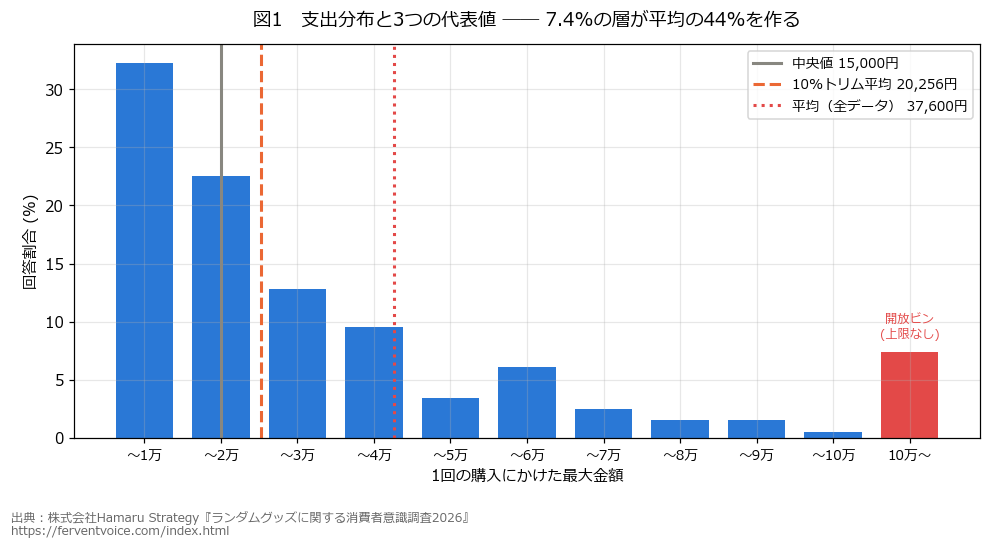

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.6))

labels = [f'〜{u}万' for u in Q11_BINS_UPPER] + ['10万〜']
heights = list(Q11_PCT_CLOSED) + [Q11_PCT_OPEN]
colors = [C_MAIN]*10 + [C_WARN]
ax.bar(range(11), heights, color=colors, width=0.75)

for m, c, ls, lab in [(Q11_MEDIAN, C_GRAY, '-', f'中央値 {Q11_MEDIAN:,}円'),
                      (Q11_MEAN_TRIM, C_SUB, '--', f'10%トリム平均 {Q11_MEAN_TRIM:,}円'),
                      (Q11_MEAN_RAW, C_WARN, ':', f'平均（全データ） {Q11_MEAN_RAW:,}円')]:
    pos = m/10000 - 0.5   # 万円ビンのインデックス位置に変換
    ax.axvline(pos, color=c, ls=ls, lw=2, label=lab)

ax.set_xticks(range(11)); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('回答割合 (%)'); ax.set_xlabel('1回の購入にかけた最大金額')
ax.set_title('図1　支出分布と3つの代表値 ── 7.4%の層が平均の44%を作る', fontsize=12, pad=12)
ax.legend(fontsize=9, loc='upper right')
ax.text(10, Q11_PCT_OPEN + 1.2, '開放ビン\n(上限なし)', ha='center', fontsize=8, color=C_WARN)
# 出典区分：出典明記（調査データそのもの）
caption(fig, SRC_SURVEY)
plt.tight_layout(); plt.savefig('fig1_spend_distribution.png', bbox_inches='tight'); plt.show()

回答者のわずか **7.4%** しかいない「10万円以上」層が、**平均値の約44%** を作っています。「平均は誰の体験でもない」ということが、比喩ではなく計算で確認できます。

報告書がこの歪みを認識した上で10%トリム平均（上下10%を除いて計算する方法）を採用している事実自体、裾の重い分布への統計的に妥当な対処です。

続いて、以降のシミュレーションで使う前提を決めます。

- **幾何分布**：n種類からランダムに1個ずつ引くとき、特定の1種を初めて当てるまでに必要な回数が従う分布。「種類数nに反比例した確率で当たる試行を繰り返す」というランダムグッズの購入行動をそのままモデル化できるため採用します
- **Zipf則**：人気ランキング上でi番目のキャラクターへの需要が「1/i」に比例するという経験則。株式会社Hamaru Strategyの調査に個々のキャラクター別人気データは含まれていないため、需要の偏りそのものは実測ではなく仮定です。Zipf則は書籍の売上・都市人口など「上位に人気が集中する」現象で広く観測される分布形であり、「人気キャラに需要が集中する」という定性的な傾向を再現する目的で採用しています（この仮定への依存は4節「言えなかったこと」に明記します）

## 3. 分析

以下5つのブロックで構成します。各ブロックの冒頭に「何を確かめるか」、末尾に「分かったこと」を書きます。

### 3-1. 支払意思額 vs 必要コスト（主役分析）

**何を確かめるか：** n種類からランダムに1種類を狙うとき、確率的に必要な期待コストと、消費者が「確定販売なら払える」と答えた額の間にどれだけ差があるかを確かめます。

n種類のランダム商品から特定の1種を得るまでの購入回数は幾何分布 Geom(p=1/n) に従います。

- 期待値 E[X] = n → 期待コストは単価の **n倍**
- 中央値 ≈ 0.69n（半分の人はこの回数以内で当たる）

In [5]:
REQUIRED_N10 = Q39_N_TYPES              # n=10で必要な期待コスト（幾何分布の期待値・倍率）
MEDIAN_N10 = int(np.ceil(np.log(0.5) / np.log(1 - 1/Q39_N_TYPES)))  # 中央値（回数）

print(f'n={Q39_N_TYPES}のとき')
print(f'  期待値（平均） : {REQUIRED_N10}個（= 単価の{REQUIRED_N10}倍）')
print(f'  中央値         : {MEDIAN_N10}個（= 単価の約{MEDIAN_N10/Q39_N_TYPES:.2f}倍）')

n=10のとき
  期待値（平均） : 10個（= 単価の10倍）
  中央値         : 7個（= 単価の約0.70倍）


**意図的に残す過程①：** 当初この分析では、設問39の「2.4倍」という数字を、全価格帯・全種類数に共通する値として扱っていました。しかし価格帯ごとの表を精査すると、これは**500円商品・50%点だけの値**であり、他の単価やパーセンタイルでは異なる倍率になることが分かりました。

さらに、設問39は「10種ランダム」という条件で固定されており、**種類数n=10でしか支払意思額を測定していません**。そのため、n=5やn=20のケースにこの倍率をそのまま当てはめる（外挿する）ことはできないと判断しました。

この判断を受けて、主役図の設計も変更しています。当初案は「必要コストの直線」と「支払意思額の直線」が交差する点を n=2.4 として示す構成でしたが、これは実測されていないnへの外挿を前提にした表現でした。実測されているのはn=10の1点だけなので、**「n=10」という1点に絞って両者を比較する構成**に変更しました。

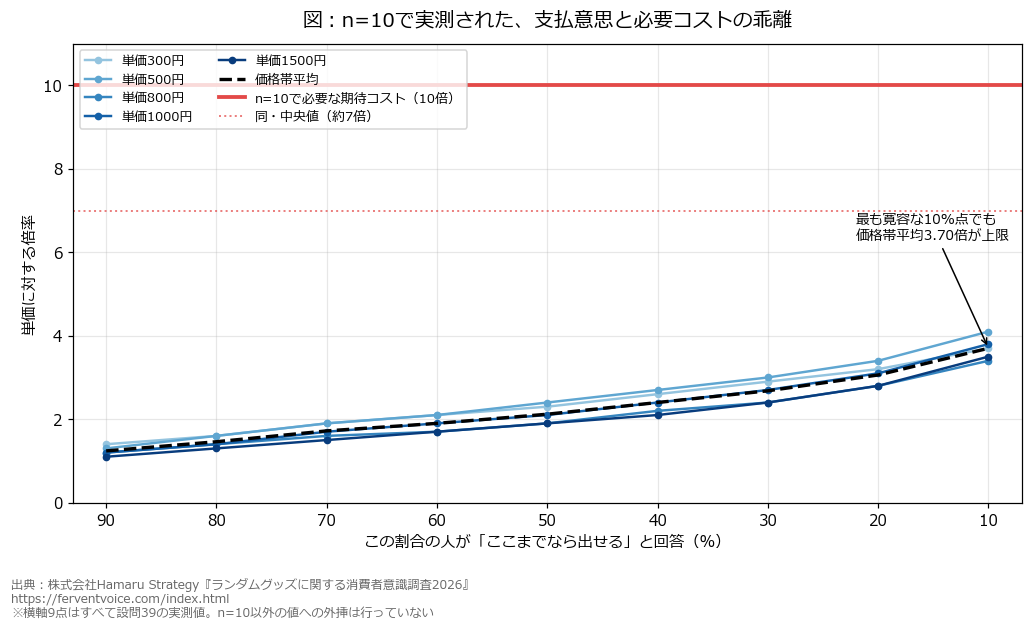

価格帯平均の倍率
   90%点  1.24倍
   80%点  1.46倍
   70%点  1.72倍
   60%点  1.90倍
   50%点  2.12倍
   40%点  2.40倍
   30%点  2.68倍
   20%点  3.06倍
   10%点  3.70倍

n=10（実測）での実額比較
  単価  300円: 必要   3,000円  払える額(50%点)    690円  払える額(寛容10%点)  1,110円
  単価  500円: 必要   5,000円  払える額(50%点)  1,200円  払える額(寛容10%点)  2,050円
  単価  800円: 必要   8,000円  払える額(50%点)  1,520円  払える額(寛容10%点)  2,720円
  単価 1000円: 必要  10,000円  払える額(50%点)  2,100円  払える額(寛容10%点)  3,800円
  単価 1500円: 必要  15,000円  払える額(50%点)  2,850円  払える額(寛容10%点)  5,250円


In [6]:
# 設問39：5つの単価 × 9パーセンタイルの許容倍率
# 「10種ランダム・うち自分の欲しい種類が1種類」に固定 → n=10の主役図と直接比較できる
avg_by_pct = {p: np.mean([Q39_MULT[pr][i] for pr in Q39_PRICES]) for i, p in enumerate(Q39_PCTS)}

fig, ax = plt.subplots(figsize=(9.5, 5.2))
cmap = plt.cm.Blues(np.linspace(0.4, 0.95, len(Q39_PRICES)))
for pr, c in zip(Q39_PRICES, cmap):
    ax.plot(Q39_PCTS, Q39_MULT[pr], 'o-', color=c, lw=1.6, ms=4, label=f'単価{pr}円')
ax.plot(Q39_PCTS, [avg_by_pct[p] for p in Q39_PCTS], 'k--', lw=2.2, label='価格帯平均')

ax.axhline(REQUIRED_N10, color=C_WARN, lw=2.5, label=f'n=10で必要な期待コスト（{REQUIRED_N10}倍）')
ax.axhline(MEDIAN_N10, color=C_WARN, lw=1.3, ls=':', alpha=.7, label=f'同・中央値（約{MEDIAN_N10}倍）')

ax.annotate(f'最も寛容な10%点でも\n価格帯平均{avg_by_pct[10]:.2f}倍が上限',
            xy=(10, avg_by_pct[10]), xytext=(22, 6.3), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='k', lw=1))

ax.set_xlim(93, 7); ax.set_ylim(0, 11)
ax.set_xlabel('この割合の人が「ここまでなら出せる」と回答（%）')
ax.set_ylabel('単価に対する倍率')
ax.set_title('図：n=10で実測された、支払意思と必要コストの乖離', fontsize=13, pad=12)
ax.legend(fontsize=8.5, loc='upper left', ncol=2)
# 出典区分：出典明記（調査データそのもの）
caption(fig, SRC_SURVEY + '\n※横軸9点はすべて設問39の実測値。n=10以外の値への外挿は行っていない')
plt.tight_layout(); plt.savefig('fig_main_cost_gap.png', bbox_inches='tight'); plt.show()

print('価格帯平均の倍率')
for p in Q39_PCTS:
    print(f'  {p:3d}%点  {avg_by_pct[p]:.2f}倍')
print()
print('n=10（実測）での実額比較')
for pr in Q39_PRICES:
    req = pr * REQUIRED_N10
    w50 = pr * Q39_MULT[pr][Q39_PCTS.index(50)]
    w10 = pr * Q39_MULT[pr][Q39_PCTS.index(10)]
    print(f'  単価{pr:>5}円: 必要 {req:>7,}円  払える額(50%点) {w50:>6,.0f}円  払える額(寛容10%点) {w10:>6,.0f}円')

**補足：** 設問44の集計表（許容ライン・拒絶ライン）を実額に直すと、許容ラインは5種×500円＝2,500円、拒絶ラインは10種×1,000円＝10,000円になります。これは設問39とは別の設問ですが、方向としては同じ結論を指しています。消費者が言語化していなかった「なんとなくの許容ライン」が、幾何分布から計算される期待コストと近い値になっているということです。

また、メーカーヒアリング（設問48）では、選んで買える場合と比べて客単価に約5〜10倍の差があるという趣旨の発言が複数社から挙がっています（一社の発言そのままではなく、複数社ヒアリングの要約です）。売る側から見た数字も、同じオーダーに収まっています。

**分かったこと：** n=10のとき必要な期待コストは単価の10倍。一方、最も支払意思の強い10%の層でも払えるのは平均3.70倍が上限で、必要額の半分にも届きません。この乖離が、ランダム販売への不満の出発点になっています。

### 3-2. 供給と需要のミスマッチ

**何を確かめるか：** 排出確率が全種類で完全に等しくても、需要（欲しい人の数）が偏っていれば、体感の不公平は生まれるのかを確かめます。

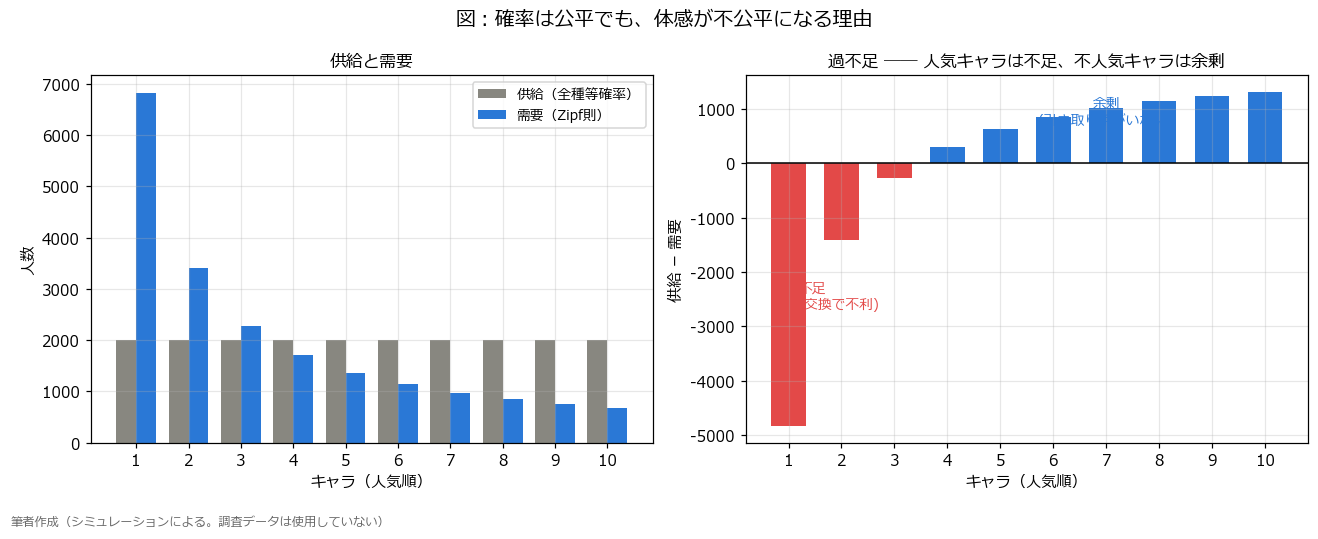

総余剰（＝総不足）: 6,519人分 / 全体の32.6%


In [7]:
N_TYPES = 10
M = 20000                                     # 消費者数
zipf_w = 1 / np.arange(1, N_TYPES + 1)        # Zipf則（s=1）による需要の重み
zipf_w = zipf_w / zipf_w.sum()

demand = M * zipf_w                            # 需要（各種を欲しい人の数）
supply = np.full(N_TYPES, M / N_TYPES)         # 供給（一様＝全種等確率）
gap = supply - demand                          # 正なら余る／負なら足りない

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))
x = np.arange(1, N_TYPES + 1); w = 0.38
a1.bar(x - w/2, supply, w, color=C_GRAY, label='供給（全種等確率）')
a1.bar(x + w/2, demand, w, color=C_MAIN, label='需要（Zipf則）')
a1.set_xlabel('キャラ（人気順）'); a1.set_ylabel('人数'); a1.set_xticks(x)
a1.set_title('供給と需要', fontsize=11); a1.legend(fontsize=9)

cols = [C_WARN if g < 0 else C_MAIN for g in gap]
a2.bar(x, gap, color=cols, width=0.65)
a2.axhline(0, color='k', lw=1)
a2.set_xlabel('キャラ（人気順）'); a2.set_ylabel('供給 − 需要'); a2.set_xticks(x)
a2.set_title('過不足 ── 人気キャラは不足、不人気キャラは余剰', fontsize=11)
a2.text(1.2, gap[0]*0.55, '不足\n(交換で不利)', color=C_WARN, fontsize=9)
a2.text(7.0, gap[-1]*0.55, '余剰\n(引き取り手がいない)', color=C_MAIN, fontsize=9, ha='center')

plt.suptitle('図：確率は公平でも、体感が不公平になる理由', fontsize=13)
# 出典区分：筆者作成（シミュレーションのみ）
caption(fig, SRC_SIM)
plt.tight_layout(); plt.savefig('fig2_supply_demand_gap.png', bbox_inches='tight'); plt.show()

total_gap = gap[gap > 0].sum()
print(f'総余剰（＝総不足）: {total_gap:,.0f}人分 / 全体の{total_gap/M:.1%}')

**分かったこと：** 供給は全種類で完全に等しく設定していますが、需要をZipf則で偏らせただけで、人気キャラは構造的に不足し、不人気キャラは構造的に余ります。誰かが確率を操作したわけではなく、「一様な供給」と「偏った需要」を掛け合わせた結果として自動的にこのミスマッチが生まれます。設問32（交換レートが存在する 70.6%）・設問33（推しが人気で交換が成立しない 67.2%）は、この構造が実際に消費者に体感されていることを裏付けています。

### 3-3. 余剰の移動（確定販売 vs ランダム販売）

**何を確かめるか：** 同じ商品を「確定販売」と「ランダム販売」で売った場合、余剰（売れ残り・ダブり）の総量と、それが誰の手元に残るかを比較します。

- **確定販売**：企業が全種類を同じ数だけ作る（人気を考慮しない一様生産）という、確定販売にとって最も分の悪いケースを仮定します。実際には人気を調査して数量を調整することもありますが、その調整には需要予測のコストがかかります
- **ランダム販売**：消費者は目当てが出るまで買います。ただし予算の上限を設けます（設問21では、ランダムだったので購入をやめた経験がある人が93.6%）

確定販売  企業側デッドストック        :     6,519 個
ランダム  消費者側ダブり(予算3個)    :    54,662 個
          うち目当てを得られず        :    14,662 人 (73.3%)
[参考]    予算上限なしの場合          :   177,231 個


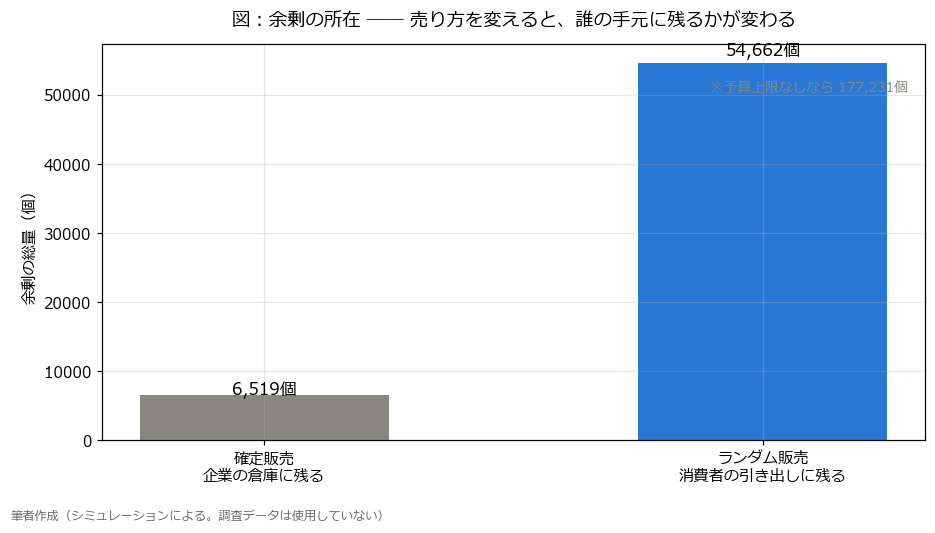

In [8]:
# 確定販売：企業が一様に生産、需要は偏る → 売れ残りが企業に残る
deadstock = np.maximum(0, supply - demand).sum()

# ランダム販売：予算上限K個まで購入して諦める
K_BUDGET = 3
targets = rng.choice(N_TYPES, size=M, p=zipf_w)
bought = rng.integers(0, N_TYPES, size=(M, K_BUDGET))
got = (bought == targets[:, None]).any(axis=1)
dupes = M * K_BUDGET - got.sum()          # 目当て以外＝消費者の手元に残る

# 参考：予算上限なし（目当てが出るまで買い続ける）＝理論上の上界
dupes_uncapped = (rng.geometric(1/N_TYPES, size=M) - 1).sum()

print(f'確定販売  企業側デッドストック        : {deadstock:>9,.0f} 個')
print(f'ランダム  消費者側ダブり(予算{K_BUDGET}個)    : {dupes:>9,.0f} 個')
print(f'          うち目当てを得られず        : {(~got).sum():>9,} 人 ({(~got).mean():.1%})')
print(f'[参考]    予算上限なしの場合          : {dupes_uncapped:>9,.0f} 個')

fig, ax = plt.subplots(figsize=(8.5, 4.6))
bars = ax.bar(['確定販売\n企業の倉庫に残る', 'ランダム販売\n消費者の引き出しに残る'],
              [deadstock, dupes], color=[C_GRAY, C_MAIN], width=0.5)
for b, v in zip(bars, [deadstock, dupes]):
    ax.text(b.get_x()+b.get_width()/2, v*1.02, f'{v:,.0f}個', ha='center', fontsize=11)
ax.set_ylabel('余剰の総量（個）')
ax.set_title('図：余剰の所在 ── 売り方を変えると、誰の手元に残るかが変わる', fontsize=12, pad=12)
ax.text(0.98, 0.88, f'※予算上限なしなら {dupes_uncapped:,.0f}個', transform=ax.transAxes,
        ha='right', fontsize=9, color=C_GRAY)
# 出典区分：筆者作成（シミュレーションのみ）
caption(fig, SRC_SIM)
plt.tight_layout(); plt.savefig('fig3_surplus_transfer.png', bbox_inches='tight'); plt.show()

**意図的に残す過程②：** 当初この比較は「目当てが出るまで買い続ける」という設定（予算上限なし）で行っていました。しかしこの設定では消費者側の余剰が企業側デッドストックの約27倍という非現実的な差になり、図にしても2本の棒の高さが違いすぎて読めませんでした。

そこで設問21（ランダムだったので購入をやめた経験がある 93.6%）を根拠に、**予算上限3個で打ち切る**という設定に変更しました。これは「消費者は実際には無限に買い続けるわけではない」という調査結果に沿った、より現実的な前提です。変更後も消費者側の余剰（約54,662個）は企業側デッドストック（約6,519個）よりはるかに大きく、結論は変わっていません。

メーカーヒアリング（設問48）には「キャラクター人気の差による在庫リスクを減らせることが大きく、やめられない」という発言があります。一方、消費者側の設問27では、不要な種類の扱いについて「保管しておく」62.0%、「廃棄する」37.6%という回答が出ています。企業が「在庫リスクが減る」と言い、消費者が「保管している・捨てている」と答えている ── 両者は同じ現象を別の側から証言していると読めます。

**分かったこと：** 余剰は消えているのではなく、企業の倉庫から消費者の手元へ移動しています。しかもランダム販売では「目当てが出るまで買う」という行動により、総購入個数自体が跳ね上がるため、総量としての余剰も増加します。

### 3-4. 交換のマッチング効果

**何を確かめるか：** ファンの間で自発的に行われている「交換」が、3-2で見た供給・需要のミスマッチをどこまで解消できるかを確かめます。ここで扱うのは個数を1個と1個で合わせる交換で、相手の見つけ方を2通りに分けて比較します。

- **①1対1で交換**：2人だけで、互いに相手の欲しいものを持っているときだけ成立。**最大マッチング**（networkx）で解きます
- **②全体で回す**：3人以上でも輪を組み、目当てを得られなかった人どうしで供給と需要を融通し合います

**前提（①②で共通）：** 目当てをすでに得た人は、交換で受け取るものが無いため交換に参加しません。供給・需要のどちらにもその人の分は含めず、①②とも**未充足者だけ**を対象に比較します。

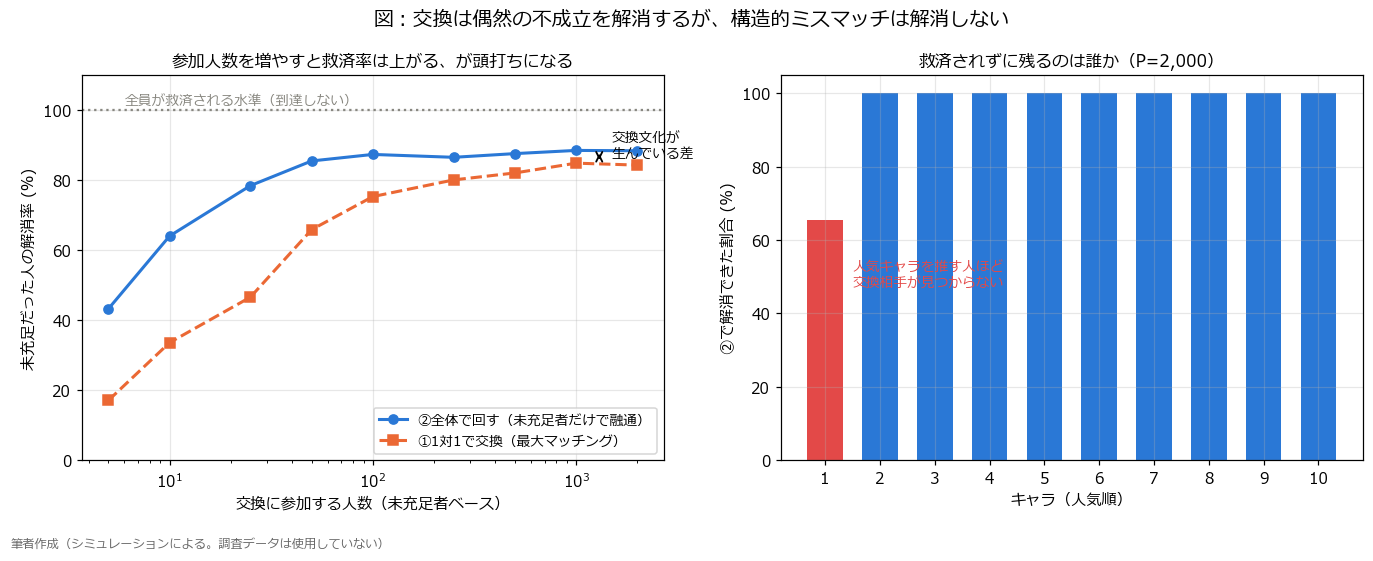

P=     5  ①1対1  17.1%   ②全体で回す  43.2%
P=    10  ①1対1  33.6%   ②全体で回す  64.0%
P=    25  ①1対1  46.6%   ②全体で回す  78.4%
P=    50  ①1対1  65.8%   ②全体で回す  85.4%
P=   100  ①1対1  75.2%   ②全体で回す  87.3%
P=   250  ①1対1  80.0%   ②全体で回す  86.4%
P=   500  ①1対1  82.0%   ②全体で回す  87.5%
P= 1,000  ①1対1  84.8%   ②全体で回す  88.4%
P= 2,000  ①1対1  84.2%   ②全体で回す  88.3%
頭打ち（P=1000,2000平均）: ①84.5%  ②88.3%  差3.9pt  届かない層11.7%


In [9]:
def simulate_exchange(P, k=K_BUDGET, n_types=N_TYPES, w=zipf_w, rng=None):
    """P人がk個ずつ購入。目当てを得られなかった人だけが交換に参加する。

    目当てを得た人は受け取るものが無いため、供給にも需要にも含めない
    （①②とも未充足者だけで比較条件を揃える）。

    返り値: (①1対1の最大マッチング成立率, ②全体で回した場合の成立率, キャラ別の②成立率)
    どちらも「目当てを得られなかった人のうち、交換で入手できた割合」。
    """
    tgt    = rng.choice(n_types, size=P, p=w)
    bought = rng.integers(0, n_types, size=(P, k))
    got    = (bought == tgt[:, None]).any(axis=1)
    unmet  = np.where(~got)[0]
    if len(unmet) == 0:
        return 1.0, 1.0, np.ones(n_types)
    have = [set(bought[i]) for i in range(P)]

    # ① 1対1：互いに相手の欲しいものを持つペアのみ。最大マッチングで解く
    G = nx.Graph()
    G.add_nodes_from(unmet)
    U = list(unmet)
    for a in range(len(U)):
        for b in range(a + 1, len(U)):
            i, j = U[a], U[b]
            if tgt[i] in have[j] and tgt[j] in have[i]:
                G.add_edge(i, j)
    one_to_one = len(nx.max_weight_matching(G)) * 2 / len(unmet)

    # ② 全体で回す：未充足者だけで供給プールと需要を作る
    pool = np.zeros(n_types, dtype=int)
    for i in unmet:
        pool += np.bincount(bought[i], minlength=n_types)
    need = np.bincount(tgt[unmet], minlength=n_types)
    matched_by_type = np.minimum(pool, need)
    circulate = matched_by_type.sum() / need.sum()
    by_type = np.divide(matched_by_type, need, out=np.ones(n_types), where=need > 0)

    return one_to_one, circulate, by_type

SEED = 20260801
Ps = np.array([5, 10, 25, 50, 100, 250, 500, 1000, 2000])
reps = lambda P: 30 if P < 250 else (12 if P < 1000 else 6)

one_pct, circ_pct = [], []
for P in Ps:
    ones, circs = [], []
    for s in range(reps(P)):
        rep_rng = np.random.default_rng(SEED + s)
        o, c, _ = simulate_exchange(P, rng=rep_rng)
        ones.append(o); circs.append(c)
    one_pct.append(np.mean(ones) * 100)
    circ_pct.append(np.mean(circs) * 100)
one_pct = np.array(one_pct)
circ_pct = np.array(circ_pct)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.8))
a1.semilogx(Ps, circ_pct, 'o-', color=C_MAIN, lw=2, ms=6, label='②全体で回す（未充足者だけで融通）')
a1.semilogx(Ps, one_pct, 's--', color=C_SUB, lw=2, ms=6, label='①1対1で交換（最大マッチング）')
a1.axhline(100, color=C_GRAY, ls=':', lw=1.5)
a1.text(6, 101.5, '全員が救済される水準（到達しない）', fontsize=9, color=C_GRAY)
a1.annotate('', xy=(1300, circ_pct[-2]), xytext=(1300, one_pct[-2]),
            arrowprops=dict(arrowstyle='<->', color='k', lw=1.2))
a1.text(1500, (circ_pct[-2] + one_pct[-2]) / 2, '交換文化が\n生んでいる差', fontsize=9)
a1.set_xlabel('交換に参加する人数（未充足者ベース）'); a1.set_ylabel('未充足だった人の解消率 (%)')
a1.set_title('参加人数を増やすと救済率は上がる、が頭打ちになる', fontsize=11)
a1.legend(fontsize=9, loc='lower right'); a1.set_ylim(0, 110)

by_t_reps = [simulate_exchange(2000, rng=np.random.default_rng(SEED + s))[2] for s in range(6)]
by_t = np.mean(by_t_reps, axis=0) * 100
a2.bar(np.arange(1, N_TYPES + 1), by_t, color=[C_WARN if v < 90 else C_MAIN for v in by_t], width=0.65)
a2.set_xticks(np.arange(1, N_TYPES + 1)); a2.set_ylim(0, 105)
a2.set_xlabel('キャラ（人気順）'); a2.set_ylabel('②で解消できた割合 (%)')
a2.set_title('救済されずに残るのは誰か（P=2,000）', fontsize=11)
a2.text(1.5, by_t[0] - 18, '人気キャラを推す人ほど\n交換相手が見つからない', fontsize=9, color=C_WARN)

plt.suptitle('図：交換は偶然の不成立を解消するが、構造的ミスマッチは解消しない', fontsize=13)
# 出典区分：筆者作成（シミュレーションのみ）
caption(fig, SRC_SIM)
plt.tight_layout(); plt.savefig('fig4_exchange_matching.png', bbox_inches='tight'); plt.show()

for P, o, c in zip(Ps, one_pct, circ_pct):
    print(f'P={P:>6,}  ①1対1 {o:5.1f}%   ②全体で回す {c:5.1f}%')
print(f'頭打ち（P=1000,2000平均）: ①{np.mean(one_pct[-2:]):.1f}%  ②{np.mean(circ_pct[-2:]):.1f}%  '
      f'差{np.mean(circ_pct[-2:]) - np.mean(one_pct[-2:]):.1f}pt  '
      f'届かない層{100 - np.mean(circ_pct[-2:]):.1f}%')


**意図的に残す過程③：** この3-4の数値は、一度分析を終えたあとに自分でモデルの誤りに気づいて修正したものです。この修正の過程こそ、なぜ最大マッチングという手法を選んだのかの証明になるため、そのまま記録として残します。

**① 最初のモデルの何が問題だったか** ①1対1のペア探索を、最初は**貪欲法**（見つかった候補から早い者勝ちでペアを決める方法）で解いていました。貪欲法は、全体を見れば2組作れる場面でも、目先の1組を優先してしまい他の人を取りこぼすことがあります。たとえば成立しうるペアが A–B、B–C、C–D という一本道のとき、Bが先にCと組んでしまうとAとDがあぶれて1組しか成立しません。全体を見て解く**最大マッチング**（networkxの`max_weight_matching`）なら、A–BとC–Dの2組が同時に成立します。

**② 比較条件が揃っていなかったこと** ②「全体で回す」側だけ、目当てをすでに得た人の余り物も供給プールに含めていました。しかしその人は交換で受け取るものが無いため、そもそも循環交換には参加しないはずです。①は未充足者だけに限定していたのに、②は全員の余りを使っていたため、①②は同じ条件で比較できていませんでした。条件を揃えたところ、②の成立率は93%台から88%台に下がり、**①②の差は12ポイントから3.8ポイントに縮まりました**。

**③ 修正によって結論がどう変わったか** 「SNSのような多者間の仕組みが大きな価値を生んでいる」という当初の解釈は成立しなくなりました。代わりに、「**最も効率的に交換しても11.7%は届かない**」という、構造的な限界の話として結論がより明確になりました。数値は動きましたが、主張の方向は変わらず、むしろ強くなっています。

**分かったこと：** 交換には確かにネットワーク効果があり、1対1より全体で回すほうが救済率は高くなります（P=2,000で①84.2% vs ②88.3%、差3.8ポイント）。ただしその差は縮まっており、人数を増やしても②は88%台で頭打ちになります。人気キャラを推す人ほど交換相手が見つからないという構造は解消されず、**最も効率的に交換しても11.7%は交換で届きません**。交換は「できることをやっている」が、供給が一様である限りその効果には上限があります。

### 3-5. BOX買い vs 単品買い

**何を確かめるか：** BOX買い（1箱に全種類が1個ずつ入っている売り方）が単品買いより本当に「お得」なのかを確かめます。単品買いは復元抽出（同じ種類が何度も出る）、BOX買いは非復元抽出（n個入りで全種1個ずつ）としてモデル化します。

【1種だけ欲しい人】
  単品  期待値 10.0個 / 中央値 7個 / 標準偏差 9.5
  BOX   10個で確定（ばらつきゼロ）

【全種欲しい人】
  単品  期待値 29.4個 / 中央値 27個（理論値 n・H_n = 29.3）
  BOX   10個で確定
  → BOXが約2.9倍おトク


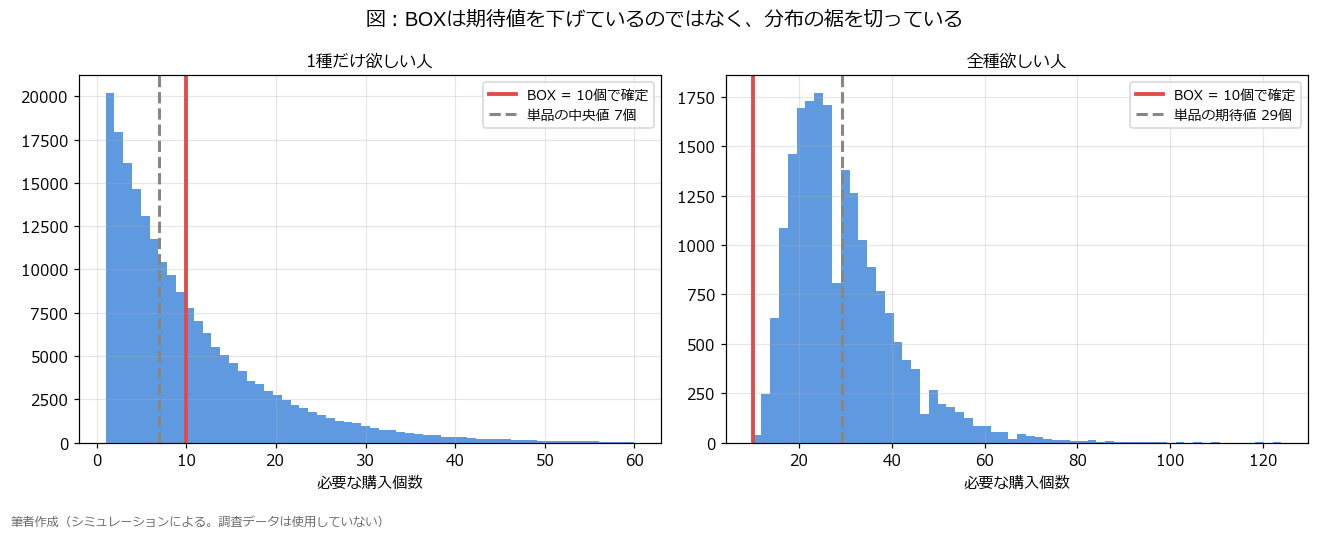

In [10]:
n_t = N_TYPES
trials = 200000

# ① 1種だけ欲しい：単品は幾何分布、BOXはn個で確定
single_one = rng.geometric(1/n_t, size=trials)

# ② 全種欲しい：クーポンコレクター問題（BOXはn個で確定）
def coupon_collector(n, size, rng):
    out = np.empty(size, dtype=int)
    for i in range(size):
        seen = np.zeros(n, bool); c = 0
        while not seen.all():
            seen[rng.integers(0, n)] = True; c += 1
        out[i] = c
    return out

coupon = coupon_collector(n_t, 20000, rng)

print('【1種だけ欲しい人】')
print(f'  単品  期待値 {single_one.mean():.1f}個 / 中央値 {np.median(single_one):.0f}個 / 標準偏差 {single_one.std():.1f}')
print(f'  BOX   {n_t}個で確定（ばらつきゼロ）')
print()
print('【全種欲しい人】')
print(f'  単品  期待値 {coupon.mean():.1f}個 / 中央値 {np.median(coupon):.0f}個'
      f'（理論値 n・H_n = {n_t*np.sum(1/np.arange(1, n_t+1)):.1f}）')
print(f'  BOX   {n_t}個で確定')
print(f'  → BOXが約{coupon.mean()/n_t:.1f}倍おトク')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6), sharey=False)
a1.hist(single_one[single_one <= 60], bins=60, color=C_MAIN, alpha=.75)
a1.axvline(n_t, color=C_WARN, lw=2.5, label=f'BOX = {n_t}個で確定')
a1.axvline(np.median(single_one), color=C_GRAY, ls='--', lw=2, label=f'単品の中央値 {np.median(single_one):.0f}個')
a1.set_title('1種だけ欲しい人', fontsize=11); a1.set_xlabel('必要な購入個数'); a1.legend(fontsize=9)

a2.hist(coupon, bins=60, color=C_MAIN, alpha=.75)
a2.axvline(n_t, color=C_WARN, lw=2.5, label=f'BOX = {n_t}個で確定')
a2.axvline(coupon.mean(), color=C_GRAY, ls='--', lw=2, label=f'単品の期待値 {coupon.mean():.0f}個')
a2.set_title('全種欲しい人', fontsize=11); a2.set_xlabel('必要な購入個数'); a2.legend(fontsize=9)

plt.suptitle('図：BOXは期待値を下げているのではなく、分布の裾を切っている', fontsize=13)
# 出典区分：筆者作成（シミュレーションのみ）
caption(fig, SRC_SIM)
plt.tight_layout(); plt.savefig('fig5_box_vs_single.png', bbox_inches='tight'); plt.show()

**分かったこと：** 「1種だけ欲しい人」と「全種欲しい人」で結論が逆転します。

- **1種だけ欲しい人**：単品買いの期待値（平均）はBOX買いと同じ10個で、中央値で比べるとむしろ単品買いのほうが7個で済み有利です。BOXが提供しているのは「平均額の引き下げ」ではなく、「30個買っても出ない」といった運の悪さによる振れ幅の解消です
- **全種欲しい人**：単品買いはクーポンコレクター問題により平均29.2個が必要で、BOX買いの10個に対し**約2.9倍不利**になります

設問38で「全種コンプリートセットの販売を望む」声が55.0%あったことは、この結果を踏まえると興味深く読めます。1種だけ欲しい人にとって確定販売は平均額を下げるものではないのに、半数以上が求めている。これは、人が期待値ではなく最悪ケースを見て判断していることの表れと読めます。1節で見た支出分布の右端（10万円以上を使った7.4%の層）は、まさにその最悪ケースを引き当てた人たちです。

## 4. 結論と限界

### 言えたこと

- **変換レートの乖離**：n=10のとき必要な期待コストは単価の10倍。一方、確定販売なら払えると答えられた額は、半数の層で単価の2.12倍、最も寛容な10%の層でも3.70倍。必要な額と、消費者が納得できる額のあいだには大きな隔たりがあります
- **余剰の移動という構造**：ランダム販売は、確定販売なら企業の倉庫に積まれるはずだった売れ残りを、消費者の引き出しへ移します。企業側の「在庫リスクを減らせる」という発言と、消費者側の「保管している・廃棄している」という回答は、同じ現象を別の側から見たものです
- **確率が公平でも需要の偏りだけで不公平感が生まれること**：供給を完全に一様に設定しても、需要が偏っていれば人気キャラは構造的に不足し、その負担は人気キャラを推す人に集中します

### 言えなかったこと

- 設問39の支払意思額データは種類数n=10でのみ測定されており、他の種類数（n=5やn=20など）への一般化はできません
- このシミュレーションが扱っているのは**個数を合わせる交換**（1個と1個）のみであり、**市場換算交換**（人気キャラ1個に対し不人気キャラを複数個付けるレート交換）は再現していません。レート交換は「束で受け取って1つでも当たれば成立」という形になるため双方向の一致という条件が緩みます。その結果が数値をどう動かすかは別途検証が必要です
- 余剰の移動モデルは企業が需要予測をしないという前提に立っており、予測精度が向上すればデッドストックは減少しうるものです
- 用いた需要分布（Zipf則）は仮定であり、実際のキャラクター人気分布を実測したものではありません

## 5. 再現方法

- **必要パッケージ**：numpy, matplotlib, networkx（バージョンは下のセルで実行環境から取得して表示します）
- **乱数シード**：`20260801` でノートブック全体を通じて固定しています
- **実行順の注意**：セルは上から順に実行してください。定数定義 → 前処理 → 分析の順に依存関係があります

In [11]:
import numpy, matplotlib, networkx
print(f'numpy      : {numpy.__version__}')
print(f'matplotlib : {matplotlib.__version__}')
print(f'networkx   : {networkx.__version__}')
print(f'random seed: 20260801（本ノートブック全体で共通）')

numpy      : 1.26.4
matplotlib : 3.8.0
networkx   : 3.1
random seed: 20260801（本ノートブック全体で共通）
